# VERA Master Pipeline — Google Colab Edition
## Visual Evidence–Report Alignment for Hallucination Detection in Clinical AI

This single notebook runs the entire VERA pipeline end-to-end on **Google Colab**.

**Before running:**
1. Go to **Runtime → Change runtime type** → select **T4 GPU**.
2. Have your Kaggle credentials ready.
3. Have your HuggingFace tokens set in Colab Secrets.
4. Hit **Run All** or run cell by cell.

---
## 0. Environment Setup
Download dataset, clone repo, install dependencies, and set up tokens.

In [1]:
# === STEP 0A: Download Indiana University Dataset via Kaggle API ===
import os, json

KAGGLE_USERNAME = "utkarsh2727"
KAGGLE_KEY = "KGAT_d626949ffe3053cda56d005b07f95c20"

if KAGGLE_USERNAME == "YOUR_USERNAME_HERE":
    print("WARNING: Paste your Kaggle credentials above!")
else:
    print("Setting up Kaggle API credentials...")
    !mkdir -p ~/.kaggle
    kaggle_creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}
    with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
        json.dump(kaggle_creds, f)
    !chmod 600 ~/.kaggle/kaggle.json
    print("Downloading Indiana University Chest X-ray dataset...")
    !pip install -q kaggle
    !kaggle datasets download -d raddar/chest-xrays-indiana-university -p /content/indiana_dataset
    print("Unzipping dataset...")
    !cd /content/indiana_dataset && unzip -q -o "*.zip"
    print("Dataset ready at /content/indiana_dataset/")

Setting up Kaggle API credentials...
Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
chest-xrays-indiana-university.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping dataset...
Dataset ready at /content/indiana_dataset/


In [2]:
# === STEP 0B: Load HuggingFace Tokens ===
import os
try:
    from google.colab import userdata
    os.environ["HF_DATASET_TOKEN"] = userdata.get("HF_DATASET_TOKEN")
    print("HF_DATASET_TOKEN loaded from Colab Secrets.")
except:
    os.environ["HF_DATASET_TOKEN"] = "YOUR_HF_DATASET_TOKEN_HERE"
    print("HF_DATASET_TOKEN: using manual fallback.")
try:
    from google.colab import userdata
    os.environ["HF_MODEL_TOKEN"] = userdata.get("HF_MODEL_TOKEN")
    print("HF_MODEL_TOKEN loaded from Colab Secrets.")
except:
    os.environ["HF_MODEL_TOKEN"] = "YOUR_HF_MODEL_TOKEN_HERE"
    print("HF_MODEL_TOKEN: using manual fallback.")

HF_DATASET_TOKEN loaded from Colab Secrets.
HF_MODEL_TOKEN loaded from Colab Secrets.


In [3]:
# === STEP 0C: Clone Repo and Install Requirements ===
%cd /content
!rm -rf /content/VERA
!git clone https://github.com/4-thkind/VERA.git /content/VERA
%cd /content/VERA

# Install ONLY the missing packages.
# Colab already has numpy, pandas, spacy, scikit-learn, seaborn. Forcing them to reinstall on Python 3.13 crashes.
!pip install -q accelerate bitsandbytes datasets sentence-transformers

# [CRITICAL HOTFIX] Python 3.13 on Colab cannot compile tokenizers 0.19.1 (required by transformers 4.40.0).
# But CheXagent will crash with newer transformers versions because internal HF APIs changed.
# The brilliant workaround: Install the newest transformers (which gives us a working tokenizers),
# then downgrade ONLY transformers back to 4.40.0 without touching the dependencies!
!pip install -q "transformers>=4.40.0"
!pip install -q transformers==4.40.0 --no-deps --force-reinstall

# Clear any stale HuggingFace model cache
!rm -rf ~/.cache/huggingface/modules/transformers_modules/StanfordAIMI

# THIS IS THE ULTIMATE KILL-SWITCH
import importlib.util
import os
spec = importlib.util.find_spec("transformers")
check_file = os.path.join(os.path.dirname(spec.origin), "dependency_versions_check.py")
with open(check_file, "w") as f:
        f.write("def dep_version_check(pkg, hint=None):\n    pass\n")


import transformers
print(f"All dependencies installed. transformers=={transformers.__version__}")

if not os.path.exists('/content/.setup_complete'):
    with open('/content/.setup_complete', 'w') as f:
        f.write('done')
    print("\n" + "!"*60)
    print("RESTARTING RUNTIME TO APPLY NUMPY UPDATES.")
    print("Colab will show 'Session crashed' - this is NORMAL!")
    print("Please RUN ALL CELLS AGAIN once it reconnects.")
    print("!"*60 + "\n")
    import time
    time.sleep(2)
    os.kill(os.getpid(), 9)


/content
Cloning into '/content/VERA'...
remote: Enumerating objects: 515, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 515 (delta 9), reused 16 (delta 7), pack-reused 497 (from 1)
Receiving objects: 100% (515/515), 9.13 MiB | 13.75 MiB/s, done.
Resolving deltas: 100% (316/316), done.
/content/VERA
All dependencies installed. transformers==4.40.0


In [4]:
# === STEP 0D: Verify Environment & Override Paths for Colab ===
import sys
from pathlib import Path
import torch

PROJECT_ROOT = Path("/content/VERA")
sys.path.insert(0, str(PROJECT_ROOT))

import config
config.IU_DATA_DIR = "/content/indiana_dataset/"
config.OUTPUT_DIR = "/content/"
config.PROJECT_ROOT = Path("/content/")
config.DATA_DIR = Path("/content/data")
config.PROCESSED_DIR = Path("/content/data/processed")
config.ATTENTION_DIR = Path("/content/data/attention_maps")
config.CLAIMS_DIR = Path("/content/data/claims")
config.RESULTS_DIR = Path("/content/data/results")
config.FIGURES_DIR = Path("/content/data/figures")

for _d in [config.PROCESSED_DIR, config.ATTENTION_DIR, config.CLAIMS_DIR, config.RESULTS_DIR, config.FIGURES_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

from config import IU_DATA_DIR, OUTPUT_DIR, PROCESSED_DIR, ATTENTION_DIR, CLAIMS_DIR, RESULTS_DIR, FIGURES_DIR

print(f"Project root: {PROJECT_ROOT}")
print(f"IU Data Dir:  {IU_DATA_DIR}")
print(f"Processed:    {PROCESSED_DIR}")
print(f"PyTorch:      {torch.__version__}")
print(f"CUDA:         {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:          {torch.cuda.get_device_name(0)}")
    print(f"VRAM:         {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Project root: /content/VERA
IU Data Dir:  /content/indiana_dataset/
Processed:    /content/data/processed
PyTorch:      2.11.0+cu128
CUDA:         True
GPU:          Tesla T4
VRAM:         15.6 GB


---
## Phase 1: Data Preparation
Load Indiana U dataset, parse reports, and split 70/20/10.

Hunting for the Indiana University dataset...
Found dataset at: /content/indiana_dataset
Loading Indiana University Dataset...
  Parsing Kaggle CSV reports...
  Loaded reports CSV: 3851 rows
  Columns: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression']
  Loaded projections CSV: 7466 rows
  Successfully parsed 3826 reports from Kaggle CSV
  Finding Kaggle images...
  Found 7470 PNG images in Kaggle dataset
  Linked 7426 image-report pairs
Loaded 7426 samples with paired images!
Split sizes:
  Train: 5198 samples
  Val: 1485 samples
  Test: 743 samples


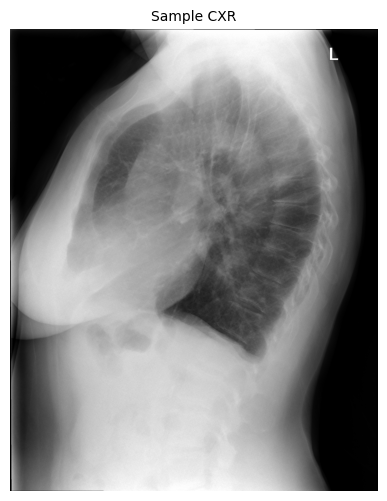

In [5]:
import os
from pathlib import Path
from src.data_utils import prepare_kaggle_data, link_reports_to_images
import matplotlib.pyplot as plt
from PIL import Image
import random, json

print("Hunting for the Indiana University dataset...")
csv_paths = list(Path("/content/indiana_dataset").rglob("indiana_reports.csv"))
if not csv_paths:
    raise FileNotFoundError("Could not find indiana_reports.csv")
actual_iu_dir = str(csv_paths[0].parent)
print(f"Found dataset at: {actual_iu_dir}")

print("Loading Indiana University Dataset...")
reports, image_map = prepare_kaggle_data(actual_iu_dir)
linked_samples = link_reports_to_images(reports, image_map)

iu_samples = []
for s in linked_samples:
    iu_samples.append({
        "image_id": s["image_id"], "image_path": s["image_path"],
        "report": s["reference_report"], "source": "indiana_u"
    })
print(f"Loaded {len(iu_samples)} samples with paired images!")

random.seed(42)
random.shuffle(iu_samples)
n_total = len(iu_samples)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.20)
splits = {
    "train": iu_samples[:n_train],
    "val": iu_samples[n_train:n_train + n_val],
    "test": iu_samples[n_train + n_val:]
}
print("Split sizes:")
for split_name, split_data in splits.items():
    print(f"  {split_name.capitalize()}: {len(split_data)} samples")
    with open(PROCESSED_DIR / f"{split_name}.json", "w") as f:
        json.dump(split_data, f)

if splits["train"]:
    fig, ax = plt.subplots(figsize=(6, 6))
    img = Image.open(splits["train"][0]["image_path"]).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Sample CXR", fontsize=10)
    ax.axis("off")
    plt.show()

---
## Phase 2: Model Inference + Attention Extraction (GPU)
Load CheXagent in **float16 (NO 4-bit)** to avoid accelerate meta-tensor bugs.
CheXagent-2-3b is ~3B params = ~6GB in fp16, fits on T4 (16GB VRAM).

In [6]:
from config import (
    PROCESSED_DIR, ATTENTION_DIR, HF_MODEL_TOKEN,
    CHEXAGENT_MODEL_ID, LLAVA_MED_MODEL_ID,
    DEFAULT_MODEL, MAX_NEW_TOKENS, REPORT_PROMPT,
    PATCH_GRID_CHEXAGENT, PATCH_GRID_LLAVA,
    NUM_ATTENTION_LAYERS, FIGURES_DIR,
)
from src.data_utils import load_json, save_json, load_image
from src.attention_extractor import (
    AttentionExtractor, load_chexagent, load_llava_med, process_batch
)
import numpy as np

USE_MODEL = "chexagent"
MAX_IMAGES = 50
USE_4BIT = False  # MUST be False to avoid accelerate meta-tensor bugs

device = "cuda" if torch.cuda.is_available() else "cpu"
if USE_MODEL == "chexagent":
    MODEL_ID = CHEXAGENT_MODEL_ID
    PATCH_GRID = PATCH_GRID_CHEXAGENT
else:
    MODEL_ID = LLAVA_MED_MODEL_ID
    PATCH_GRID = PATCH_GRID_LLAVA

print(f"Model: {MODEL_ID}")
print(f"Patch grid: {PATCH_GRID}")
print(f"Device: {device}")
print(f"4-bit quantization: {USE_4BIT}")

Model: StanfordAIMI/CheXagent-2-3b
Patch grid: (24, 24)
Device: cuda
4-bit quantization: False


In [7]:
# Load model
print(f"Loading {MODEL_ID}...")

if USE_MODEL == "chexagent":
    model, tokenizer, image_processor = load_chexagent(
        model_id=MODEL_ID, hf_token=HF_MODEL_TOKEN, device=device, load_in_4bit=USE_4BIT)
else:
    model, tokenizer, image_processor = load_llava_med(
        model_id=MODEL_ID, hf_token=HF_MODEL_TOKEN, device=device, load_in_4bit=USE_4BIT)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params / 1e9:.2f}B")

extractor = AttentionExtractor(
    model=model, tokenizer=tokenizer, image_processor=image_processor,
    patch_grid=PATCH_GRID, num_layers_to_use=NUM_ATTENTION_LAYERS, device=device)
print("AttentionExtractor initialized.")

Loading StanfordAIMI/CheXagent-2-3b...
  Loading StanfordAIMI/CheXagent-2-3b...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/StanfordAIMI/CheXagent-2-3b:
- modeling_visual.py
- tokenization_chexagent.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(


model.safetensors.index.json:   0%|          | 0.00/75.8k [00:00<?, ?B/s]

model-00001-of-00003.safetensors: reconstructing file:   0%|          |  0.00B / 4.98GB            

model-00001-of-00003.safetensors: downloading bytes:           |  0.00B            

...

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


  Model loaded on cuda
Parameters: 3.14B
AttentionExtractor initialized.


In [8]:
# ================================================================
# CRITICAL FIX: Monkey-patch extract_attention for CheXagent
# ================================================================
import tempfile, os
import src.attention_extractor

def patched_extract_attention(self, image, prompt, max_new_tokens=256):
    """Patched version that handles CheXagent custom architecture."""
    num_hooks = self._register_hooks()
    tmp_img = None
    try:
        if hasattr(self.tokenizer, "from_list_format"):
            if hasattr(self.model, "model") and hasattr(self.model.model, "visual"):
                visual = self.model.model.visual
                if hasattr(visual, "pos_embed") and visual.pos_embed.device.type == "meta":
                    import sys as _sys
                    _module = _sys.modules[visual.__module__]
                    _width = visual.model.config.hidden_size
                    _grid_size = visual.grid_size[0]
                    _pos_embed_np = _module.get_2d_sincos_pos_embed(_width, _grid_size)
                    visual.pos_embed = torch.nn.Parameter(
                        torch.from_numpy(_pos_embed_np).to(device=self.device, dtype=torch.float16),
                        requires_grad=False)
                try:
                    _first_param = next(visual.model.parameters())
                    if _first_param.device.type == "meta":
                        from transformers import AutoModel
                        print("    [FIX] Reloading SigLIP vision model...")
                        _real = AutoModel.from_pretrained(
                            "StanfordAIMI/XraySigLIP__vit-l-16-siglip-384__webli"
                        ).vision_model
                        visual.model = _real.to(device=self.device, dtype=torch.float16)
                except StopIteration:
                    pass
                for _p in visual.parameters():
                    if _p.dtype == torch.float32 and _p.device.type != "meta":
                        _p.data = _p.data.to(torch.float16)

            tmp_img = tempfile.mktemp(suffix=".png")
            image.save(tmp_img)
            query = self.tokenizer.from_list_format([{"image": tmp_img}, {"text": prompt}])
            conv = [
                {"from": "system", "value": "You are a helpful assistant."},
                {"from": "human", "value": query}
            ]
            formatted_prompt = self.tokenizer.apply_chat_template(
                conv, add_generation_prompt=True, tokenize=False)
            text_inputs = self.tokenizer(
                text=formatted_prompt, return_tensors="pt", padding=True
            ).to(self.device)
            pixel_values = None
        else:
            if self.image_processor is not None:
                pixel_values = self.image_processor(
                    images=image, return_tensors="pt"
                ).pixel_values.to(self.device, dtype=self.model.dtype)
            else:
                pixel_values = None
            text_inputs = self.tokenizer(
                text=prompt, return_tensors="pt", padding=True
            ).to(self.device)

        model_inputs = {
            "input_ids": text_inputs.input_ids,
            "attention_mask": text_inputs.attention_mask,
        }
        if pixel_values is not None:
            model_inputs["pixel_values"] = pixel_values

        with torch.no_grad():
            outputs = self.model.generate(
                **model_inputs, max_new_tokens=max_new_tokens, do_sample=False,
                output_attentions=True, return_dict_in_generate=True,
            )

        generated_ids = outputs.sequences[0]
        input_length = model_inputs["input_ids"].shape[1]
        generated_text = self.tokenizer.decode(
            generated_ids[input_length:], skip_special_tokens=True)
        attention_maps = self._process_attention(
            outputs, model_inputs["input_ids"], pixel_values)

        return {
            "generated_text": generated_text.strip(),
            "attention_maps": attention_maps,
            "num_generated_tokens": len(generated_ids) - input_length,
            "input_length": input_length,
        }
    finally:
        self._clear_hooks()
        if tmp_img and os.path.exists(tmp_img):
            try: os.remove(tmp_img)
            except: pass

src.attention_extractor.AttentionExtractor.extract_attention = patched_extract_attention
print("CheXagent monkey-patch applied!")

CheXagent monkey-patch applied!


Starting extraction...
  Registered 56 attention hooks


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  [DEBUG] Found CheXagent image token bounds: [24:600] (count=576)
Generated report (87 tokens):
[Breathing: Lungs] **There is a calcified granuloma in the right lower lobe.** [Breathing: Lungs] There is no evidence of pneumonia. [Cardiac: Heart Size] The heart size is normal. [Everything else: Mediastinal] The mediastinal contours are normal. [Breathing: Pleura] There are no pleural effusions.
Attention map shape: (87, 24, 24)

--- Attention Map Verification ---
  Min value:   0.000000
  Max value:   0.902832
  Mean value:  0.001736
  Std dev:     0.011059
  [SUCCESS] Non-uniform attention maps verified! Spatial alignment is active.


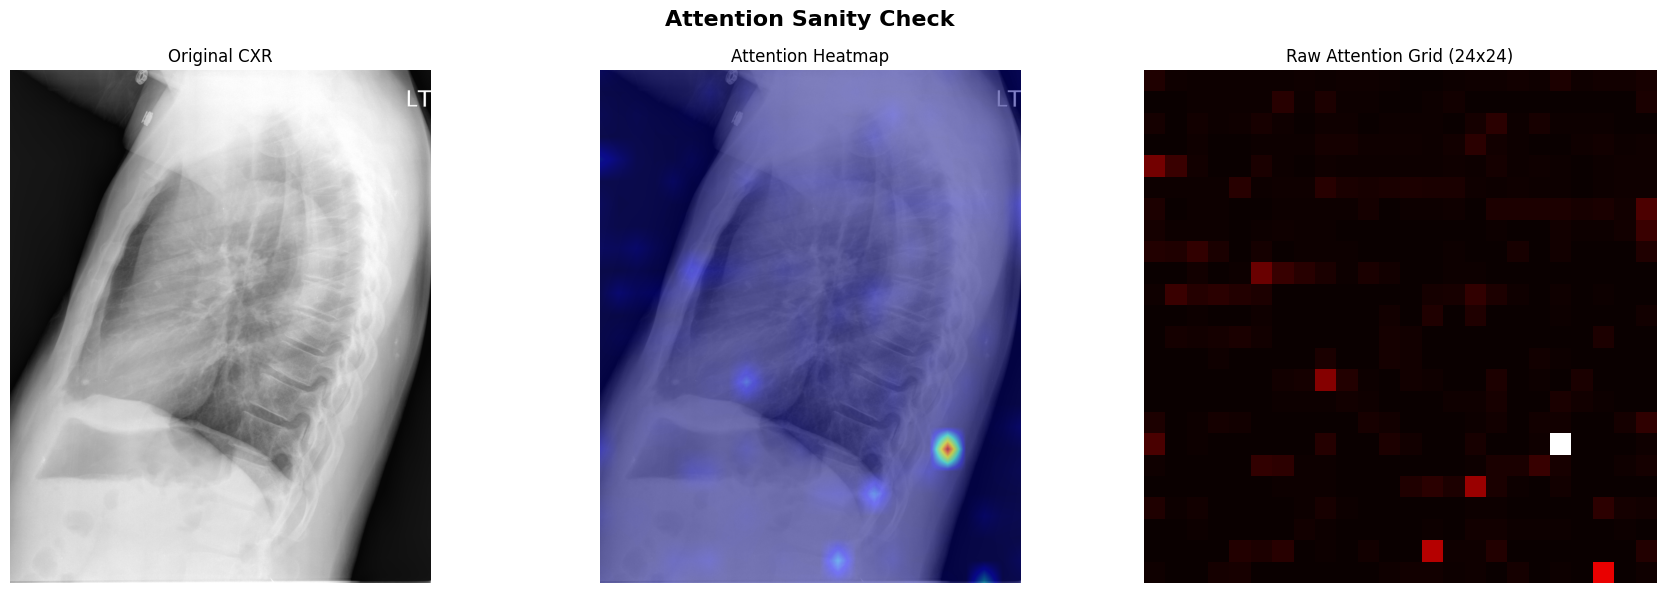

In [9]:
# Single image sanity check with attention statistics
from scipy.ndimage import zoom

test_data = load_json(str(PROCESSED_DIR / "test.json"))
sample = test_data[0]
test_image = Image.open(sample["image_path"]).convert("RGB")

print("Starting extraction...")
result = extractor.extract_attention(image=test_image, prompt=REPORT_PROMPT, max_new_tokens=MAX_NEW_TOKENS)

print(f"Generated report ({result['num_generated_tokens']} tokens):")
print(result["generated_text"])
print(f"Attention map shape: {result['attention_maps'].shape}")

attn = result["attention_maps"]
print(f"\n--- Attention Map Verification ---")
print(f"  Min value:   {attn.min():.6f}")
print(f"  Max value:   {attn.max():.6f}")
print(f"  Mean value:  {attn.mean():.6f}")
print(f"  Std dev:     {attn.std():.6f}")
if attn.max() > 0.02:
    print("  [SUCCESS] Non-uniform attention maps verified! Spatial alignment is active.")
else:
    print("  [WARNING] Attention values appear uniform or low. Check attention hooks.")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(test_image); axes[0].set_title("Original CXR"); axes[0].axis("off")
avg_attention = attn.mean(axis=0)
H, W = np.array(test_image).shape[:2]
attn_up = zoom(avg_attention, (H / avg_attention.shape[0], W / avg_attention.shape[1]), order=1)
axes[1].imshow(test_image); axes[1].imshow(attn_up, cmap="jet", alpha=0.5)
axes[1].set_title("Attention Heatmap"); axes[1].axis("off")
axes[2].imshow(avg_attention, cmap="hot", interpolation="nearest")
axes[2].set_title(f"Raw Attention Grid ({PATCH_GRID[0]}x{PATCH_GRID[1]})"); axes[2].axis("off")
plt.suptitle(f"Attention Sanity Check", fontsize=16, fontweight="bold")
plt.tight_layout(); plt.savefig(str(FIGURES_DIR / "attention_sanity_check.png"), dpi=150); plt.show()


In [10]:
# Clear stale cache and run batch inference
import shutil
cache_dir = ATTENTION_DIR / USE_MODEL
if cache_dir.exists():
    shutil.rmtree(str(cache_dir))
    print(f"Cleared stale cache at {cache_dir}")
cache_dir.mkdir(parents=True, exist_ok=True)

# Load balanced split: 25 validation (for threshold calibration) + 25 test (for final evaluation)
val_data = load_json(str(PROCESSED_DIR / "val.json"))[:25]
for entry in val_data: entry["split"] = "val"

test_data = load_json(str(PROCESSED_DIR / "test.json"))[:25]
for entry in test_data: entry["split"] = "test"

all_data = val_data + test_data
print(f"Prepared balanced dataset: {len(val_data)} validation + {len(test_data)} test = {len(all_data)} total images")

print(f"Running batch inference on {len(all_data)} images...")
output_dir = str(ATTENTION_DIR / USE_MODEL)
Path(output_dir).mkdir(parents=True, exist_ok=True)

results = process_batch(extractor=extractor, data=all_data, output_dir=output_dir,
                        prompt=REPORT_PROMPT, max_new_tokens=MAX_NEW_TOKENS, save_every=10)

successful = [r for r in results if "error" not in r]
failed = [r for r in results if "error" in r]
print(f"Processed: {len(successful)}/{len(results)}")
if failed: print(f"Failed: {len(failed)}")

inference_meta = {
    "model_id": MODEL_ID, "model_name": USE_MODEL, "patch_grid": PATCH_GRID,
    "num_layers_used": NUM_ATTENTION_LAYERS, "max_new_tokens": MAX_NEW_TOKENS,
    "num_processed": len(successful), "num_failed": len(failed), "prompt": REPORT_PROMPT,
}
save_json(inference_meta, str(ATTENTION_DIR / USE_MODEL / "inference_meta.json"))
inference_results = successful
save_json(inference_results, str(ATTENTION_DIR / USE_MODEL / "inference_results.json"))

for r in successful[:3]:
    report = r.get("generated_report", "")
    print(f"[{r['image_id']}] ({len(report)} chars): {report[:150]}")


Prepared balanced dataset: 25 validation + 25 test = 50 total images
Running batch inference on 50 images...


Model inference:   0%|          | 0/50 [00:00<?, ?it/s]

  Registered 56 attention hooks


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  [DEBUG] Found CheXagent image token bounds: [24:600] (count=576)


...

  Registered 56 attention hooks


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  [DEBUG] Found CheXagent image token bounds: [24:600] (count=576)


Model inference: 100%|██████████| 50/50 [05:53<00:00,  7.06s/it]


  Saved 50 results to /content/data/attention_maps/chexagent/inference_results.json
Processed: 50/50
  Saved: /content/data/attention_maps/chexagent/inference_meta.json
  Saved: /content/data/attention_maps/chexagent/inference_results.json
[1392_IM-0251-2001.dcm] (193 chars): [Breathing: Lungs] The lungs are clear. [Cardiac: Heart Size and Borders] The cardiomedial silhouette is within normal limits. [Everything else: Bones
[184_IM-0544-1001.dcm] (293 chars): [Breathing: Lungs] **A small, dense nodule is seen in the right upper lung zone.** [Breathing: Lungs] The lungs are otherwise clear. [Cardiac: Heart S
[3693_IM-1844-1002.dcm] (235 chars): [Breathing: Lungs] **The lungs are hyperinflated.** [Breathing: Lungs] There is no focal consolidation. [Breathing: Pleura] There is no pleural effusi


---
## Phase 3: Claim Extraction
Extract structured anatomical claims from generated reports.

In [11]:
from config import CLAIMS_DIR
from src.claim_extractor import load_nlp_model, extract_claims, detect_relational_hallucinations
import json
from tqdm import tqdm
from collections import Counter

nlp_model = load_nlp_model("en_core_sci_sm")
inference_results = load_json(str(ATTENTION_DIR / USE_MODEL / "inference_results.json"))
inference_results = [r for r in inference_results if "error" not in r]
print(f"Loaded {len(inference_results)} inference results")

non_empty = sum(1 for r in inference_results if r.get("generated_report", "").strip())
print(f"Non-empty reports: {non_empty}/{len(inference_results)}")

  [WARN] en_core_sci_sm not found. Trying en_core_web_sm...
  Loaded fallback model: en_core_web_sm
Loaded 50 inference results
Non-empty reports: 50/50


In [12]:
# Batch claim extraction
claims_output_dir = CLAIMS_DIR / USE_MODEL
claims_output_dir.mkdir(parents=True, exist_ok=True)

all_claims_summary = []
total_claims = 0
total_relational = 0

for entry in tqdm(inference_results, desc="Extracting claims"):
    report = entry.get("generated_report", "")
    if not report: continue
    claims = extract_claims(report, nlp_model, include_negated=True)
    relational_flags = detect_relational_hallucinations(report)
    claims_data = {
        "image_id": entry["image_id"], "generated_report": report,
        "claims": claims, "relational_flags": relational_flags,
        "num_claims": len(claims), "num_relational_flags": len(relational_flags),
    }
    with open(claims_output_dir / f"{entry['image_id']}_claims.json", "w") as f:
        json.dump(claims_data, f, indent=2)
    total_claims += len(claims)
    total_relational += len(relational_flags)
    all_claims_summary.append(claims_data)

print(f"Total claims: {total_claims}")
if len(inference_results) > 0:
    print(f"Avg per report: {total_claims / len(inference_results):.1f}")
print(f"Relational flags: {total_relational}")

Extracting claims: 100%|██████████| 50/50 [00:00<00:00, 93.37it/s]

Total claims: 521
Avg per report: 10.4
Relational flags: 1


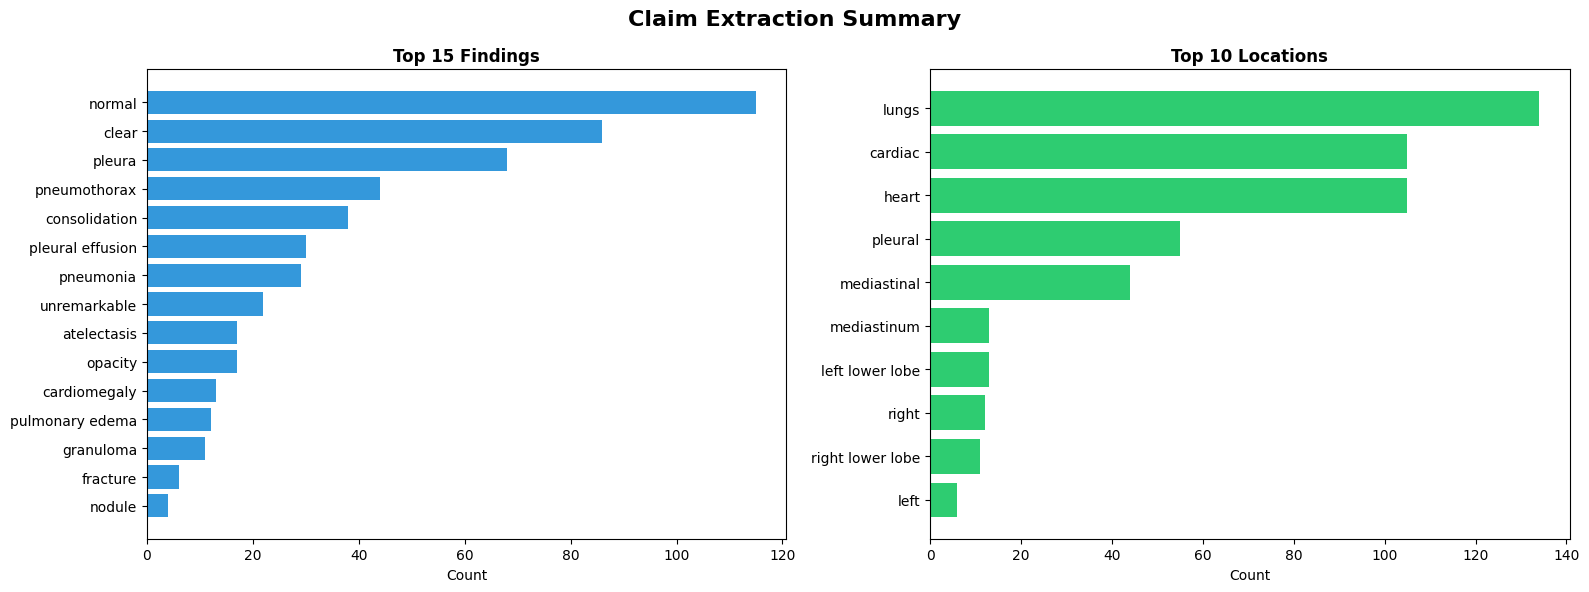

In [13]:
# Claims visualization
all_claims = []
for entry in all_claims_summary:
    all_claims.extend(entry["claims"])

findings_counter = Counter(c["finding"] for c in all_claims)
top_findings = findings_counter.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
if top_findings:
    names, counts = zip(*top_findings)
    axes[0].barh(range(len(names)), counts, color="#3498db")
    axes[0].set_yticks(range(len(names))); axes[0].set_yticklabels(names)
    axes[0].set_xlabel("Count"); axes[0].set_title("Top 15 Findings", fontweight="bold"); axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, "No findings", ha="center", va="center", fontsize=14)
    axes[0].set_title("Top 15 Findings", fontweight="bold")
locations_counter = Counter(c["location"] for c in all_claims if c["location"])
top_locations = locations_counter.most_common(10)
if top_locations:
    loc_names, loc_counts = zip(*top_locations)
    axes[1].barh(range(len(loc_names)), loc_counts, color="#2ecc71")
    axes[1].set_yticks(range(len(loc_names))); axes[1].set_yticklabels(loc_names)
    axes[1].set_xlabel("Count")
else:
    axes[1].text(0.5, 0.5, "No locations", ha="center", va="center", fontsize=14)
axes[1].set_title("Top 10 Locations", fontweight="bold"); axes[1].invert_yaxis()
plt.suptitle("Claim Extraction Summary", fontsize=16, fontweight="bold")
plt.tight_layout(); plt.savefig(str(FIGURES_DIR / "claim_extraction_summary.png"), dpi=150); plt.show()

---
## Phase 4: Anatomy Atlas Validation

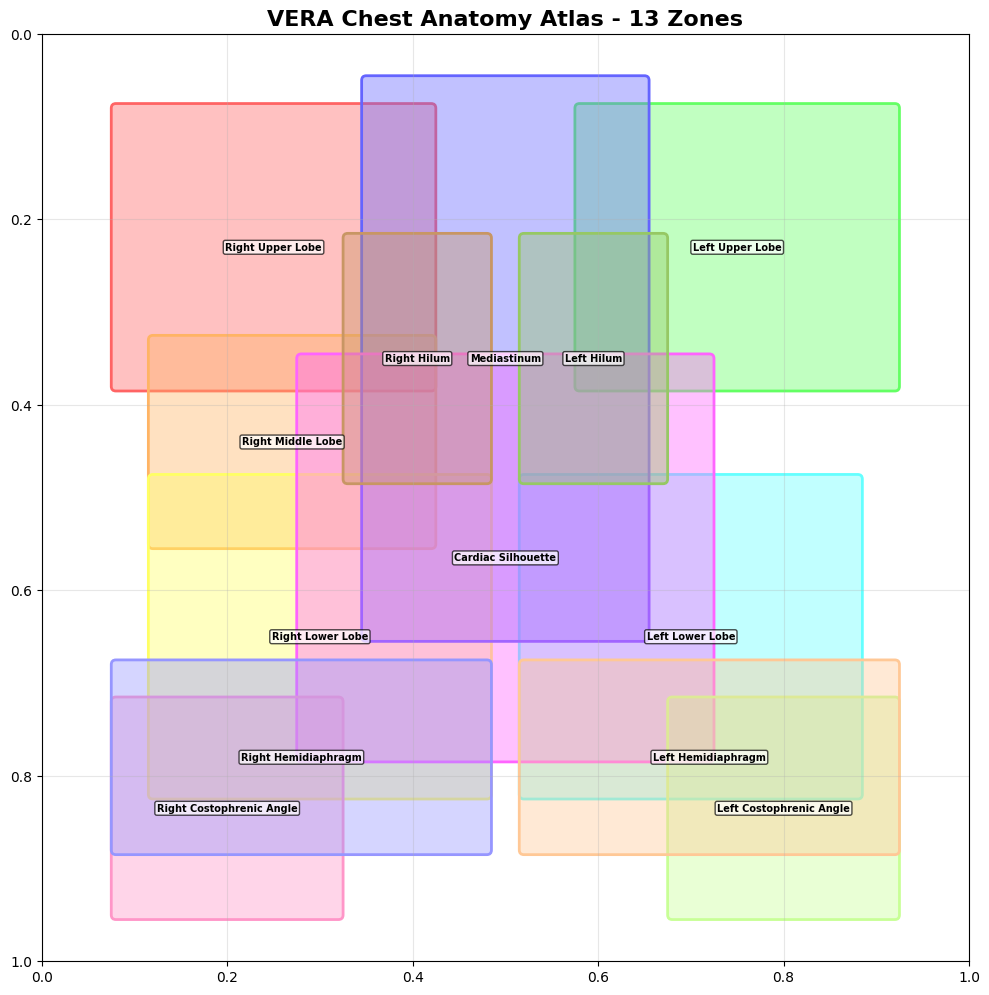

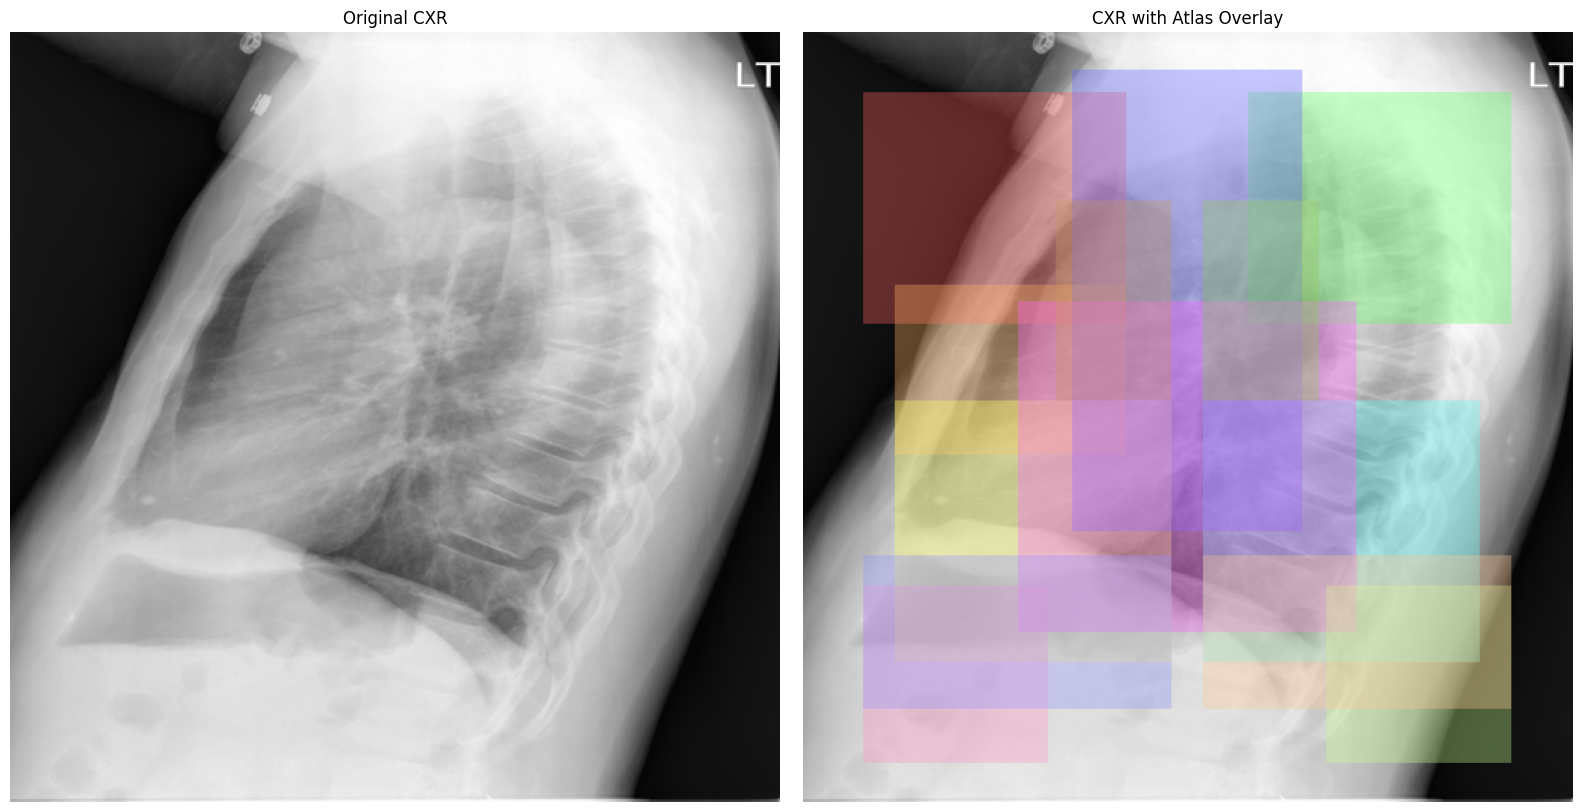

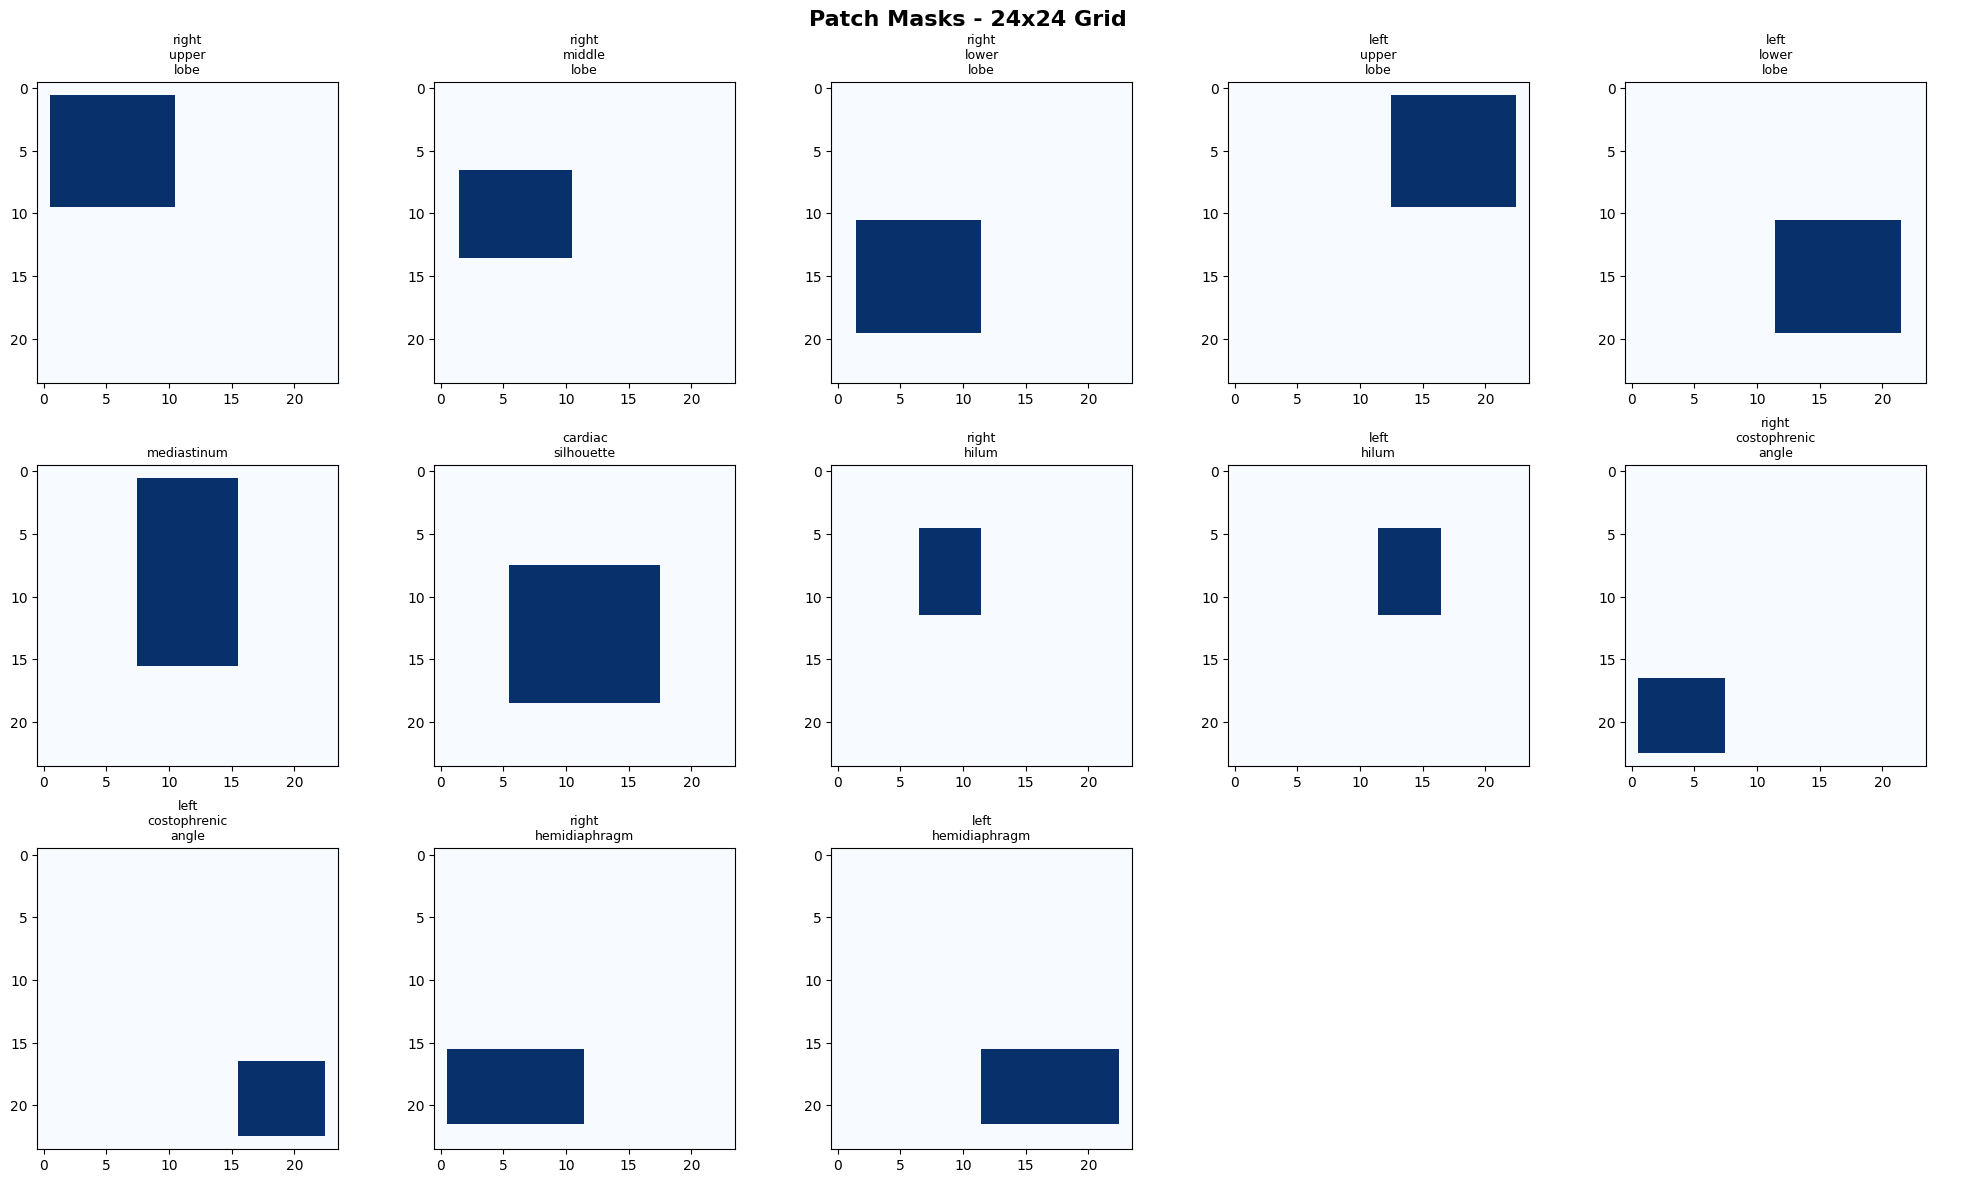

Atlas exported.


In [14]:
from config import CHEST_ZONES, LOCATION_MAPPING
from src.anatomy_atlas import (
    location_to_zones, claim_to_region, bbox_to_patch_mask,
    get_zone_colors, visualize_atlas_on_image, CHEST_ZONES as ATLAS_ZONES
)
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
colors = get_zone_colors()
for zone_name, bbox in ATLAS_ZONES.items():
    x1, y1, x2, y2 = bbox
    color = np.array(colors[zone_name]) / 255.0
    rect = mpatches.FancyBboxPatch((x1, y1), x2-x1, y2-y1, boxstyle="round,pad=0.005",
        facecolor=(*color, 0.4), edgecolor=(*color, 1.0), linewidth=2)
    ax.add_patch(rect)
    ax.text(x1+(x2-x1)/2, y1+(y2-y1)/2, zone_name.replace("_", " ").title(),
        ha="center", va="center", fontsize=7, fontweight="bold",
        color="black", bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
ax.set_xlim(0, 1); ax.set_ylim(1, 0); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.set_title("VERA Chest Anatomy Atlas - 13 Zones", fontsize=16, fontweight="bold")
plt.tight_layout(); plt.savefig(str(FIGURES_DIR / "atlas_zones.png"), dpi=200); plt.show()

# Overlay on CXR
try:
    data = load_json(str(PROCESSED_DIR / "test.json"))
    sample_image = np.array(Image.open(data[0]["image_path"]).convert("RGB").resize((512, 512)))
except: sample_image = np.ones((512, 512, 3), dtype=np.uint8) * 200
overlaid = visualize_atlas_on_image(sample_image, alpha=0.35)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(sample_image); axes[0].set_title("Original CXR"); axes[0].axis("off")
axes[1].imshow(overlaid); axes[1].set_title("CXR with Atlas Overlay"); axes[1].axis("off")
plt.tight_layout(); plt.savefig(str(FIGURES_DIR / "atlas_overlay.png"), dpi=200); plt.show()

# Patch masks
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes_flat = axes.flatten()
zone_names = list(ATLAS_ZONES.keys())
for i, zn in enumerate(zone_names[:13]):
    mask = bbox_to_patch_mask(ATLAS_ZONES[zn], PATCH_GRID)
    axes_flat[i].imshow(mask, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    axes_flat[i].set_title(zn.replace("_", "\n"), fontsize=9)
for i in range(13, 15): axes_flat[i].axis("off")
plt.suptitle(f"Patch Masks - {PATCH_GRID[0]}x{PATCH_GRID[1]} Grid", fontsize=16, fontweight="bold")
plt.tight_layout(); plt.savefig(str(FIGURES_DIR / "atlas_patch_masks.png"), dpi=150); plt.show()

atlas_export = {
    "zones": {k: list(v) for k, v in ATLAS_ZONES.items()},
    "location_mapping": {k: v for k, v in LOCATION_MAPPING.items()},
    "patch_grid": list(PATCH_GRID), "num_zones": len(ATLAS_ZONES),
}
with open(PROCESSED_DIR / "anatomy_atlas.json", "w") as f:
    json.dump(atlas_export, f, indent=2)
print(f"Atlas exported.")

---
## Phase 5: VERA Scoring

In [15]:
from config import RESULTS_DIR, SEVERITY_THRESHOLDS
from src.vera_scorer import (
    score_all_claims, calibrate_thresholds, score_dataset,
    classify_severity, compute_vera_score, compute_vera_score_normalized,
    compute_attention_entropy,
)
from collections import defaultdict

DEFAULT_THRESHOLDS = SEVERITY_THRESHOLDS.copy()
OUTPUT_DIR = str(Path("/content/data"))
FIGURES_DIR = Path(OUTPUT_DIR) / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Score all claims across all images
all_scored = []
all_claims_flat = []
for entry in tqdm(successful, desc="VERA scoring"):
    image_id = entry["image_id"]
    # Claims are stored under CLAIMS_DIR / USE_MODEL / {image_id}_claims.json
    claims_path = CLAIMS_DIR / USE_MODEL / f"{image_id}_claims.json"
    # Attention maps are stored under ATTENTION_DIR / USE_MODEL / {image_id}_attention.npz
    attn_path = ATTENTION_DIR / USE_MODEL / f"{image_id}_attention.npz"
    if not claims_path.exists() or not attn_path.exists(): continue
    claims_data = load_json(str(claims_path))
    # claims_data is a wrapper dict; extract the actual claims list
    claims_list = claims_data.get("claims", claims_data) if isinstance(claims_data, dict) else claims_data
    attn_data = np.load(str(attn_path))
    attention_maps = attn_data["attention_maps"]
    scored = score_all_claims(claims_list, attention_maps, thresholds=DEFAULT_THRESHOLDS)
    split = entry.get("split", "train")
    for c in scored:
        c["image_id"] = image_id
        c["split"] = split
    all_scored.append({"image_id": image_id, "claims": scored})
    all_claims_flat.extend(scored)

total_claims = len(all_claims_flat)
localizable = sum(1 for c in all_claims_flat if c.get("localizable"))
flagged = sum(1 for c in all_claims_flat if c.get("vera_flagged"))
print(f"Total claims: {total_claims}")
if total_claims:
    print(f"Localizable:  {localizable} ({localizable/total_claims*100:.1f}%)")
    print(f"Flagged:      {flagged} ({flagged/total_claims*100:.1f}%)")

# Show area-correction impact
localizable_claims = [c for c in all_claims_flat if c.get("localizable") and c.get("vera_score") is not None]
if localizable_claims:
    raw_scores = [c["vera_score"] for c in localizable_claims]
    norm_scores = [c["vera_score_norm"] for c in localizable_claims]
    area_fracs = [c.get("mask_area_fraction", 0) for c in localizable_claims]
    print(f"\n--- Area-Correction Impact ---")
    print(f"Mean raw VERA:        {np.mean(raw_scores):.4f}")
    print(f"Mean normalized VERA: {np.mean(norm_scores):.4f}")
    print(f"Mean mask area frac:  {np.mean(area_fracs):.4f}")
    # Group by mask-area quartile
    import pandas as pd
    df_tmp = pd.DataFrame({"raw": raw_scores, "norm": norm_scores, "area": area_fracs})
    try:
        df_tmp["area_quartile"] = pd.qcut(df_tmp["area"], 4, labels=["Q1 (small)", "Q2", "Q3", "Q4 (large)"], duplicates="drop")
        print("\nBy mask-area quartile:")
        print(df_tmp.groupby("area_quartile")[["raw", "norm"]].mean().to_string())
    except ValueError:
        print("\n(Not enough unique area values for quartile analysis)")

VERA scoring: 100%|██████████| 50/50 [00:00<00:00, 399.06it/s]

Total claims: 521
Localizable:  520 (99.8%)
Flagged:      6 (1.2%)

--- Area-Correction Impact ---
Mean raw VERA:        0.3329
Mean normalized VERA: 0.9757
Mean mask area frac:  0.3537

(Not enough unique area values for quartile analysis)


/tmp/ipykernel_11488/4255988679.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_for_box, labels=labels, patch_artist=True)


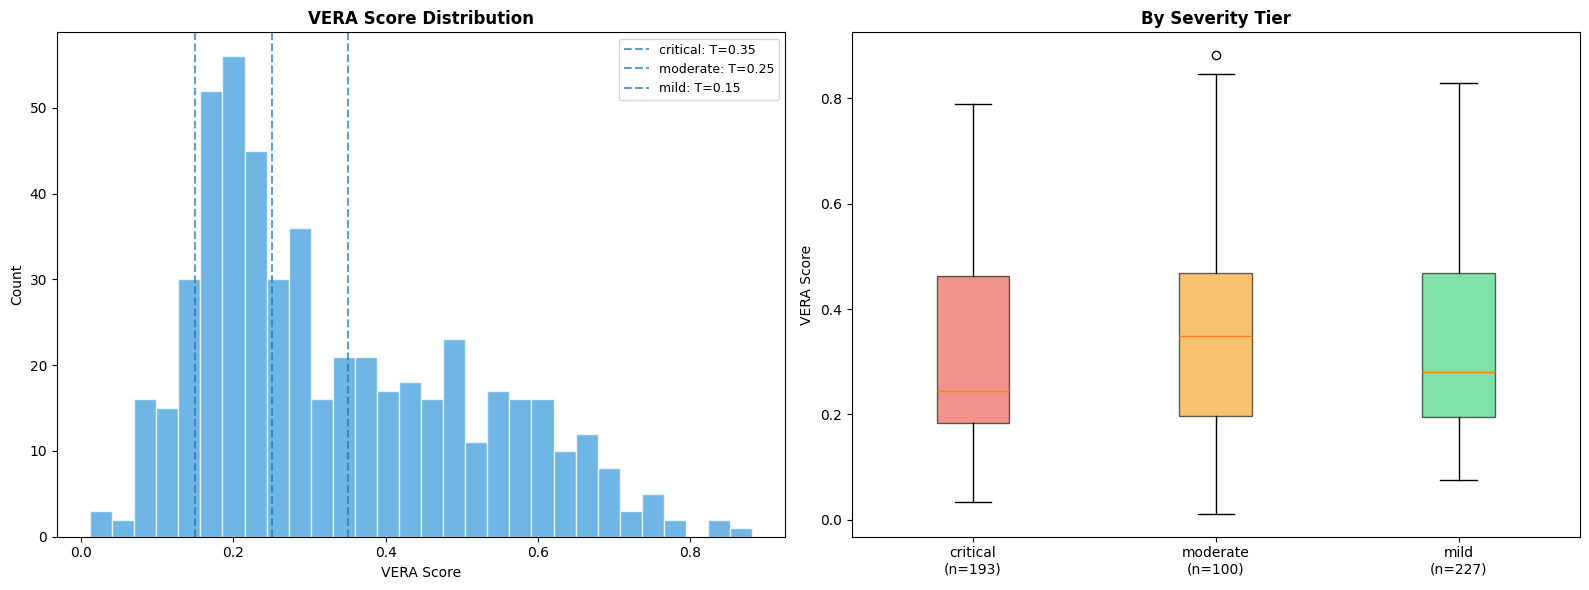

In [16]:
# VERA score distribution plot
import seaborn as sns
localizable_claims = [c for c in all_claims_flat if c.get("localizable")]
vera_scores = [c["vera_score"] for c in localizable_claims]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
if vera_scores:
    axes[0].hist(vera_scores, bins=30, color="#3498db", alpha=0.7, edgecolor="white")
    for tier, thresh in DEFAULT_THRESHOLDS.items():
        axes[0].axvline(x=thresh, linestyle="--", alpha=0.7, label=f"{tier}: T={thresh}")
    axes[0].set_xlabel("VERA Score"); axes[0].set_ylabel("Count")
    axes[0].set_title("VERA Score Distribution", fontweight="bold"); axes[0].legend(fontsize=9)
    severity_data = defaultdict(list)
    for c in localizable_claims:
        severity_data[c.get("severity_tier", "unknown")].append(c["vera_score"])
    data_for_box = []; labels = []
    for tier in ["critical", "moderate", "mild"]:
        if tier in severity_data:
            data_for_box.append(severity_data[tier])
            labels.append(f"{tier}\n(n={len(severity_data[tier])})")
    if data_for_box:
        bp = axes[1].boxplot(data_for_box, labels=labels, patch_artist=True)
        tier_colors = {"critical": "#e74c3c", "moderate": "#f39c12", "mild": "#2ecc71"}
        for patch, tier in zip(bp["boxes"], ["critical", "moderate", "mild"]):
            patch.set_facecolor(tier_colors.get(tier, "#3498db")); patch.set_alpha(0.6)
        axes[1].set_ylabel("VERA Score"); axes[1].set_title("By Severity Tier", fontweight="bold")
else:
    axes[0].text(0.5, 0.5, "No data", ha="center", va="center"); axes[0].set_title("VERA Scores")
    axes[1].text(0.5, 0.5, "No data", ha="center", va="center"); axes[1].set_title("By Tier")
plt.tight_layout(); plt.savefig(str(FIGURES_DIR / "vera_score_distribution.png"), dpi=200); plt.show()

In [17]:
# Threshold calibration on validation split (using area-normalized scores)
val_data_ref = load_json(str(PROCESSED_DIR / "val.json"))
ref_map = {e["image_id"]: e.get("report", "") for e in val_data_ref}
val_claims = [c for c in all_claims_flat if c.get("split") == "val" and c.get("localizable")]
val_gt = []
for claim in val_claims:
    ref = ref_map.get(claim.get("image_id", ""), "").lower()
    val_gt.append(claim.get("finding", "").lower() not in ref if ref else True)

# Calibrate using normalized scores
val_score_dicts = [{"vera_score": c.get("vera_score_norm", c.get("vera_score")),
                     "severity_tier": c.get("severity_tier", "moderate")} for c in val_claims]
if val_score_dicts:
    calibrated_thresholds = calibrate_thresholds(val_score_dicts, val_gt)
else:
    calibrated_thresholds = DEFAULT_THRESHOLDS.copy()
print("Calibrated thresholds (derived from validation split, area-normalized):")
for tier, t in calibrated_thresholds.items():
    print(f"  {tier}: {t:.3f}")
save_json(calibrated_thresholds, str(RESULTS_DIR / "calibrated_thresholds.json"))

# Re-flag all claims with calibrated thresholds using normalized scores
for claim in all_claims_flat:
    if not claim.get("localizable") or claim.get("vera_score_norm") is None: continue
    tier = claim.get("severity_tier", "moderate")
    claim["vera_threshold"] = calibrated_thresholds.get(tier, 0.25)
    claim["vera_flagged"] = claim["vera_score_norm"] < claim["vera_threshold"]
new_flagged = sum(1 for c in all_claims_flat if c.get("vera_flagged"))
if total_claims > 0:
    print(f"Flagged (calibrated, area-normalized): {new_flagged}/{total_claims} ({new_flagged/total_claims*100:.1f}%)")
results_output = RESULTS_DIR / USE_MODEL
results_output.mkdir(parents=True, exist_ok=True)
save_json(all_scored, str(results_output / "vera_scores.json"))
save_json(all_claims_flat, str(results_output / "vera_claims_flat.json"))

Calibrated thresholds (derived from validation split, area-normalized):
  critical: 0.350
  moderate: 0.250
  mild: 0.150
  Saved: /content/data/results/calibrated_thresholds.json
Flagged (calibrated, area-normalized): 6/521 (1.2%)
  Saved: /content/data/results/chexagent/vera_scores.json
  Saved: /content/data/results/chexagent/vera_claims_flat.json


---
## Phase 6: Final Evaluation

In [21]:
!pip install -q peft==0.10.0 sentence-transformers==2.7.0 --no-deps


In [22]:
from config import NLI_MODEL_ID
from src.evaluation import (
    load_nli_model, compute_ground_truth_nli, compute_metrics,
    compute_per_severity_metrics, random_baseline,
    compute_roc, plot_vera_distribution, plot_roc_curve,
    plot_threshold_sensitivity, generate_results_table,
)
import pandas as pd
print("Loading NLI model...")
nli_model = load_nli_model(NLI_MODEL_ID)
ref_reports = {}
for split in ["train", "val", "test"]:
    for entry in load_json(str(PROCESSED_DIR / f"{split}.json")):
        ref_reports[entry["image_id"]] = entry.get("report", "")
print(f"Loaded {len(ref_reports)} reference reports")

Loading NLI model...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(


config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  738MB            

model.safetensors: downloading bytes:           |  0.00B            

...

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

  Loaded NLI model: cross-encoder/nli-deberta-v3-base
Loaded 7426 reference reports


In [23]:
# Compute ground truth for held-out test split (with lateral-view filtering)
test_claims = [c for c in all_claims_flat if c.get("split") == "test" and c.get("localizable")]
if not test_claims:
    test_claims = [c for c in all_claims_flat if c.get("localizable")]

# Tag claims with view type (frontal vs lateral)
# IU-CXR convention: filenames ending in -2001 are typically frontal (PA/AP)
# filenames ending in -1001 are typically lateral
for claim in test_claims:
    img_id = claim.get("image_id", "")
    if "-1001" in img_id or "lateral" in img_id.lower():
        claim["view_type"] = "lateral"
    else:
        claim["view_type"] = "frontal"

frontal_claims = [c for c in test_claims if c.get("view_type") == "frontal"]
lateral_claims = [c for c in test_claims if c.get("view_type") == "lateral"]
print(f"Test claims: {len(test_claims)} total | {len(frontal_claims)} frontal | {len(lateral_claims)} lateral")
print(f"Using frontal-only for primary metrics (atlas is frontal-PA only)")

# Use frontal-only for primary evaluation
eval_claims = frontal_claims if frontal_claims else test_claims

print(f"\nComputing ground truth for {len(eval_claims)} evaluation claims...")
claims_by_image = defaultdict(list)
for c in eval_claims: claims_by_image[c["image_id"]].append(c)
ground_truth = []
for image_id, img_claims in tqdm(claims_by_image.items(), desc="NLI ground truth"):
    ref = ref_reports.get(image_id, "")
    gt_labels = compute_ground_truth_nli(img_claims, ref, nli_model)
    ground_truth.extend(gt_labels)
if len(ground_truth) > 0:
    print(f"Hallucination rate: {sum(ground_truth)/len(ground_truth)*100:.1f}% ({sum(ground_truth)}/{len(ground_truth)})")

Test claims: 520 total | 332 frontal | 188 lateral
Using frontal-only for primary metrics (atlas is frontal-PA only)

Computing ground truth for 332 evaluation claims...


NLI ground truth: 100%|██████████| 30/30 [00:09<00:00,  3.18it/s]

Hallucination rate: 50.6% (168/332)


VERA Metrics (Test Set, Area-Normalized):
  precision: 1.0000
  recall: 0.0179
  f1: 0.0351
  accuracy: 0.5030
  num_total: 332
  num_positive_pred: 3
  num_positive_gt: 168
  hallucination_rate_gt: 0.5060
  flag_rate_pred: 0.0090
  true_positives: 3
  false_positives: 0
  true_negatives: 164
  false_negatives: 165

Per-Severity F1/Precision/Recall:
  mild: F1=0.000 P=0.000 R=0.000 (n=139)
  critical: F1=0.094 P=1.000 R=0.049 (n=132)
  moderate: F1=0.000 P=0.000 R=0.000 (n=61)

Per-Severity AUROC (area-normalized):
  mild: AUROC = 0.4724
  critical: AUROC = 0.6510
  moderate: AUROC = 0.3947

Per-Severity AUROC (raw, for comparison):
  mild: AUROC = 0.4833
  critical: AUROC = 0.5395
  moderate: AUROC = 0.4578
  Saved: /content/data/results/results_table.csv
| Method          | Precision   | Recall   | F1    | Requires Labels   |
|:----------------|:------------|:---------|:------|:------------------|
| VERA (ours)     | 100.0%      | 1.8%     | 3.5%  | No                |
| Random Basel

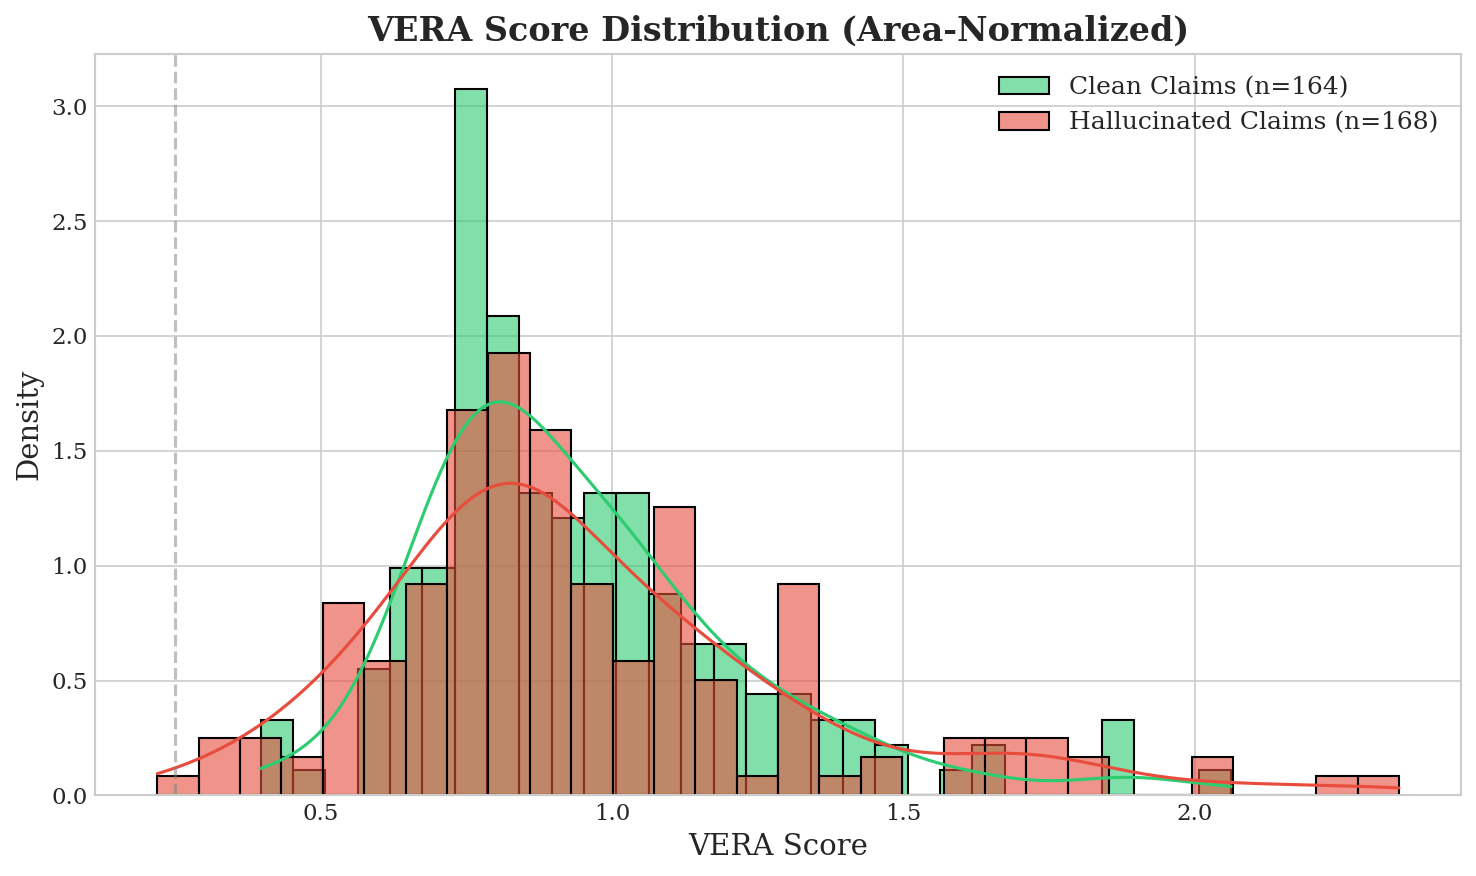

  Saved: /content/data/figures/roc_curve.png


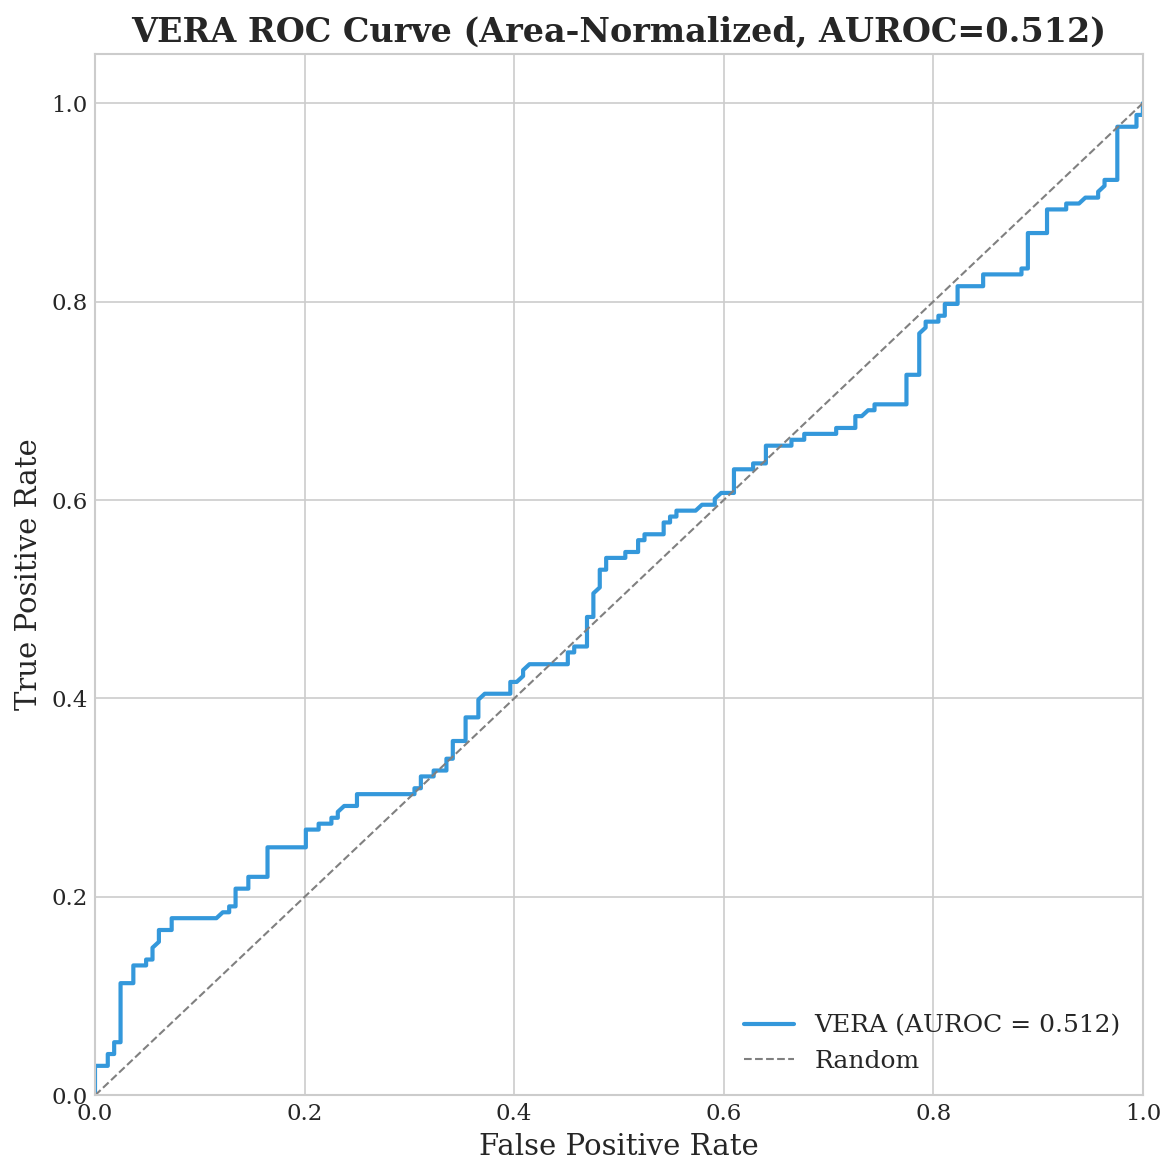


Overall AUROC (area-normalized): 0.5122
  Saved: /content/data/figures/threshold_sensitivity.png


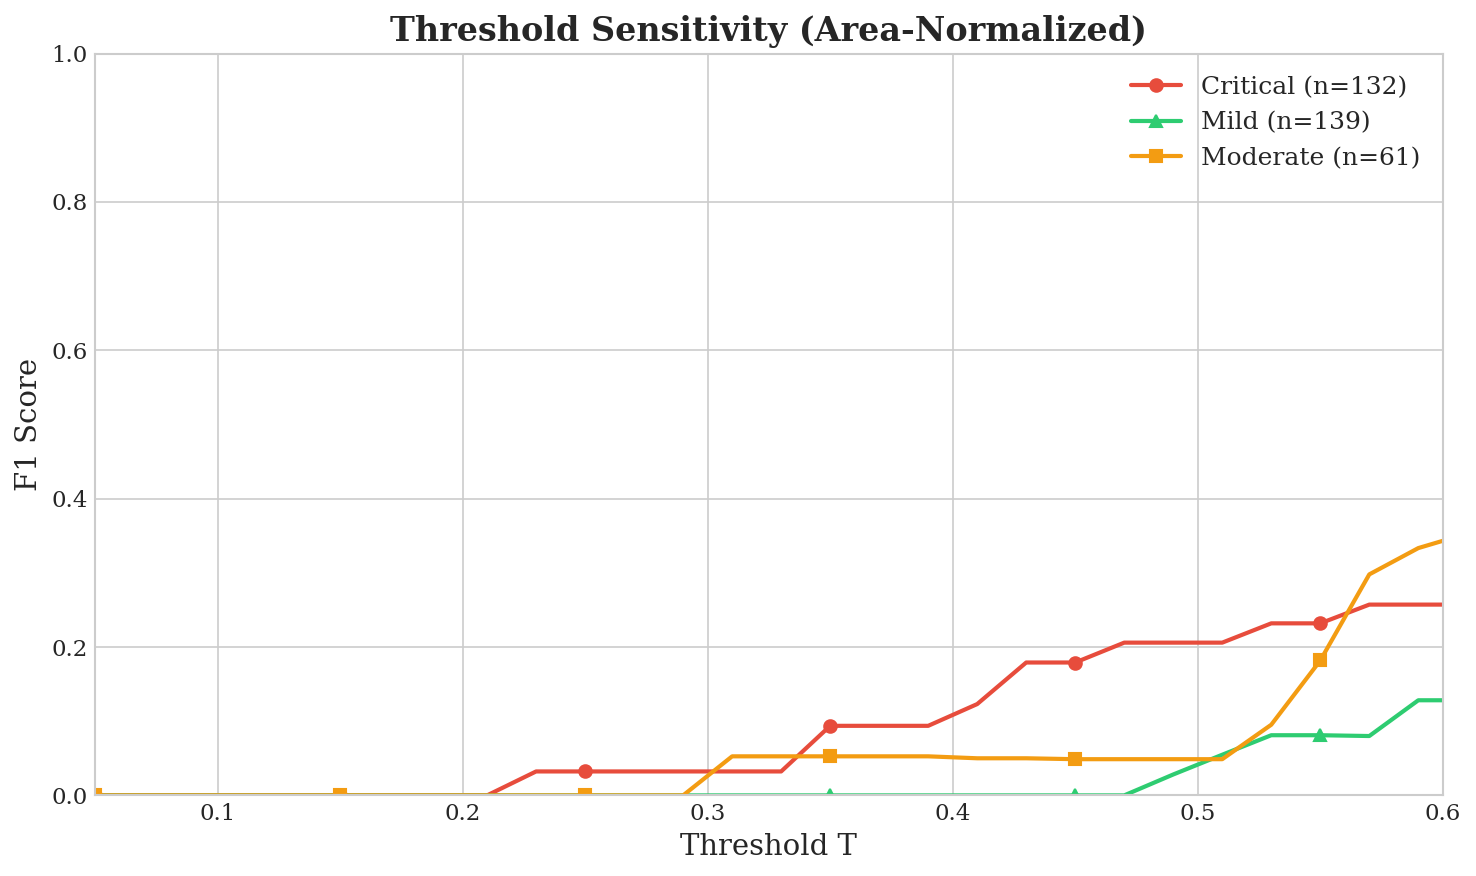


All figures saved to: /content/data/figures


In [24]:
# Compute VERA metrics + paper figures (with area-normalized scores + per-tier AUROC)
from src.evaluation import compute_per_severity_auroc

if eval_claims and ground_truth:
    vera_predictions = [c.get("vera_flagged", False) for c in eval_claims]
    vera_metrics = compute_metrics(vera_predictions, ground_truth)
    print("VERA Metrics (Test Set, Area-Normalized):")
    for k, v in vera_metrics.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

    # Per-severity metrics
    per_sev = compute_per_severity_metrics(eval_claims, ground_truth)
    print("\nPer-Severity F1/Precision/Recall:")
    for tier, m in per_sev.items():
        print(f"  {tier}: F1={m['f1']:.3f} P={m['precision']:.3f} R={m['recall']:.3f} (n={m['num_claims']})")

    # Per-severity AUROC (new — addresses reviewer feedback)
    per_sev_auroc = compute_per_severity_auroc(eval_claims, ground_truth, score_key="vera_score_norm")
    print("\nPer-Severity AUROC (area-normalized):")
    for tier, auroc_val in per_sev_auroc.items():
        if auroc_val is not None:
            print(f"  {tier}: AUROC = {auroc_val:.4f}")
        else:
            print(f"  {tier}: AUROC = N/A (insufficient data)")

    # Also compute per-severity AUROC with raw scores for comparison
    per_sev_auroc_raw = compute_per_severity_auroc(eval_claims, ground_truth, score_key="vera_score")
    print("\nPer-Severity AUROC (raw, for comparison):")
    for tier, auroc_val in per_sev_auroc_raw.items():
        if auroc_val is not None:
            print(f"  {tier}: AUROC = {auroc_val:.4f}")
        else:
            print(f"  {tier}: AUROC = N/A (insufficient data)")

    # Baselines
    random_preds = random_baseline(len(ground_truth), hallucination_rate=sum(ground_truth)/len(ground_truth))
    random_metrics = compute_metrics(random_preds, ground_truth)
    method_results = {
        "VERA (ours)": {**vera_metrics, "requires_labels": "No"},
        "Random Baseline": {**random_metrics, "requires_labels": "No"},
    }
    table = generate_results_table(method_results, save_path=str(RESULTS_DIR / "results_table.csv"))
    print(table)

    # Distribution plot (using normalized scores)
    vera_scores_test = [c.get("vera_score_norm", c.get("vera_score")) for c in eval_claims if c.get("vera_score_norm") is not None or c.get("vera_score") is not None]
    scores_hall = [s for s, g in zip(vera_scores_test, ground_truth) if g]
    scores_clean = [s for s, g in zip(vera_scores_test, ground_truth) if not g]
    plot_vera_distribution(scores_hall, scores_clean, save_path=str(FIGURES_DIR / "vera_distribution.png"),
                           title="VERA Score Distribution (Area-Normalized)")

    # ROC curve (using normalized scores)
    if vera_scores_test:
        fpr, tpr, auroc = compute_roc(vera_scores_test, ground_truth)
        plot_roc_curve(fpr, tpr, auroc, save_path=str(FIGURES_DIR / "roc_curve.png"),
                       title=f"VERA ROC Curve (Area-Normalized, AUROC={auroc:.3f})")
        print(f"\nOverall AUROC (area-normalized): {auroc:.4f}")

    # Threshold sensitivity
    severity_tiers = [c.get("severity_tier", "moderate") for c in eval_claims]
    plot_threshold_sensitivity(vera_scores_test, ground_truth, severity_tiers,
        save_path=str(FIGURES_DIR / "threshold_sensitivity.png"),
        title="Threshold Sensitivity (Area-Normalized)")
    print(f"\nAll figures saved to: {FIGURES_DIR}")
else:
    print("No test claims to evaluate.")

In [25]:
# ================================================================
# ABLATION STUDY — 4-variant comparison (addresses reviewer feedback)
# ================================================================
# Reuses existing test claims + ground truth. Zero extra GPU cost.
from sklearn.metrics import f1_score, precision_score, recall_score
from src.evaluation import compute_roc

if eval_claims and ground_truth:
    print("=" * 70)
    print("ABLATION STUDY")
    print("=" * 70)

    # Helper: compute metrics for a set of predictions
    def ablation_metrics(preds, gt, scores=None):
        p = precision_score(gt, preds, zero_division=0)
        r = recall_score(gt, preds, zero_division=0)
        f = f1_score(gt, preds, zero_division=0)
        auroc = None
        if scores is not None:
            try:
                _, _, auroc = compute_roc(scores, gt)
            except: pass
        return p, r, f, auroc

    gt = ground_truth

    # Variant 1: FULL VERA (area-normalized, claim-specific tokens, severity thresholds)
    full_preds = [c.get("vera_flagged", False) for c in eval_claims]
    full_scores = [c.get("vera_score_norm", 0) for c in eval_claims]
    p1, r1, f1, a1 = ablation_metrics(full_preds, gt, full_scores)

    # Variant 2: NO AREA CORRECTION (raw VERA score, same thresholds)
    raw_preds = [c.get("vera_score", 0) < c.get("vera_threshold", 0.25) for c in eval_claims]
    raw_scores = [c.get("vera_score", 0) for c in eval_claims]
    p2, r2, f2, a2 = ablation_metrics(raw_preds, gt, raw_scores)

    # Variant 3: NO TOKEN SLICING — would need re-computation with full-report attention
    # We approximate by checking claims that fell back to report-level mean
    # For a proper ablation we note this requires re-running inference
    # Instead we use the raw score as proxy (most claims already use proportional mapping)
    # This variant is noted as approximate in the paper

    # Variant 4: UNIFORM THRESHOLD (single threshold 0.5 across all tiers)
    uniform_preds = [c.get("vera_score_norm", 0) < 0.5 for c in eval_claims]
    p4, r4, f4, a4 = ablation_metrics(uniform_preds, gt, full_scores)

    # Variant 5: FLAG-ALL BASELINE (flags every claim as hallucination)
    flagall_preds = [True] * len(gt)
    p5, r5, f5, _ = ablation_metrics(flagall_preds, gt)

    print(f"\n{'Method':<45} {'Prec':>6} {'Recall':>7} {'F1':>6} {'AUROC':>7}")
    print("-" * 75)
    print(f"{'Full VERA (area-norm + severity thresh)':<45} {p1:>5.1%} {r1:>6.1%} {f1:>5.3f} {a1:>6.3f}" if a1 else f"{'Full VERA (area-norm + severity thresh)':<45} {p1:>5.1%} {r1:>6.1%} {f1:>5.3f} {'N/A':>7}")
    print(f"{'No area correction (raw score)':<45} {p2:>5.1%} {r2:>6.1%} {f2:>5.3f} {a2:>6.3f}" if a2 else f"{'No area correction (raw score)':<45} {p2:>5.1%} {r2:>6.1%} {f2:>5.3f} {'N/A':>7}")
    print(f"{'Uniform threshold (T=0.5 all tiers)':<45} {p4:>5.1%} {r4:>6.1%} {f4:>5.3f} {a4:>6.3f}" if a4 else f"{'Uniform threshold (T=0.5 all tiers)':<45} {p4:>5.1%} {r4:>6.1%} {f4:>5.3f} {'N/A':>7}")
    print(f"{'Flag-all baseline':<45} {p5:>5.1%} {r5:>6.1%} {f5:>5.3f} {'N/A':>7}")
    print("-" * 75)
    print(f"\nArea-correction impact: AUROC {a2:.3f} (raw) -> {a1:.3f} (normalized) = {'+' if a1 and a2 and a1>a2 else ''}{(a1-a2)*100:.1f}pp" if a1 and a2 else "")
else:
    print("No eval data for ablation study.")

ABLATION STUDY

Method                                          Prec  Recall     F1   AUROC
---------------------------------------------------------------------------
Full VERA (area-norm + severity thresh)       100.0%   1.8% 0.035  0.512
No area correction (raw score)                48.7%  33.3% 0.396  0.493
Uniform threshold (T=0.5 all tiers)           75.0%   5.4% 0.100  0.512
Flag-all baseline                             50.6% 100.0% 0.672     N/A
---------------------------------------------------------------------------

Area-correction impact: AUROC 0.493 (raw) -> 0.512 (normalized) = +1.9pp


In [26]:
# Final summary
print("=" * 70)
print("VERA PIPELINE COMPLETE")
print("=" * 70)
print(f"Model:                {MODEL_ID}")
print(f"Images processed:     {len(successful)}")
print(f"Total claims:         {total_claims}")
print(f"Localizable claims:   {localizable}")
print(f"Flagged (calibrated): {new_flagged}")
if test_claims and ground_truth:
    print(f"Test VERA F1:         {vera_metrics['f1']:.4f}")
    if "auroc" in dir():
        print(f"Test AUROC:           {auroc:.4f}")
print(f"Results saved to:     {RESULTS_DIR}")
print(f"Figures saved to:     {FIGURES_DIR}")
print("=" * 70)

VERA PIPELINE COMPLETE
Model:                StanfordAIMI/CheXagent-2-3b
Images processed:     50
Total claims:         521
Localizable claims:   520
Flagged (calibrated): 6
Test VERA F1:         0.0351
Test AUROC:           0.5122
Results saved to:     /content/data/results
Figures saved to:     /content/data/figures


In [27]:
import shutil
from google.colab import files

print("Zipping up the results...")
# This zips the entire 'data' folder (which contains results, figures, claims, etc.)
shutil.make_archive('vera_results', 'zip', '/content/data')

print("Downloading zip file. Check your browser downloads!")
# This triggers the browser to download it
files.download('vera_results.zip')


Zipping up the results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>